In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Task 2 started successfully")

Task 2 started successfully


In [2]:
import pandas as pd
import os

base_path = os.path.dirname(os.getcwd())
file_path = os.path.join(base_path, "data", "AAPL.csv")

df = pd.read_csv(file_path)
df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   str    
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 177.0 KB


Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df[['Open','High','Low','Close','Volume']] = df[['Open','High','Low','Close','Volume']].astype(float)

## Moving Averages

This section computes Simple Moving Averages (SMA) and Exponential Moving Averages (EMA) to identify stock price trends over time.

In [5]:
# Simple Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Exponential Moving Averages
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()

df[['Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail()

,Close,SMA_20,SMA_50,EMA_20,EMA_50
3769,191.788757,191.856618,183.572859,191.510231,186.389576
3770,191.243912,192.018094,183.858864,191.484867,186.579942
3771,191.342972,192.154308,184.149424,191.471353,186.766728
3772,191.768951,192.362839,184.479567,191.499696,186.962893
3773,190.728775,192.490633,184.814828,191.426275,187.110575


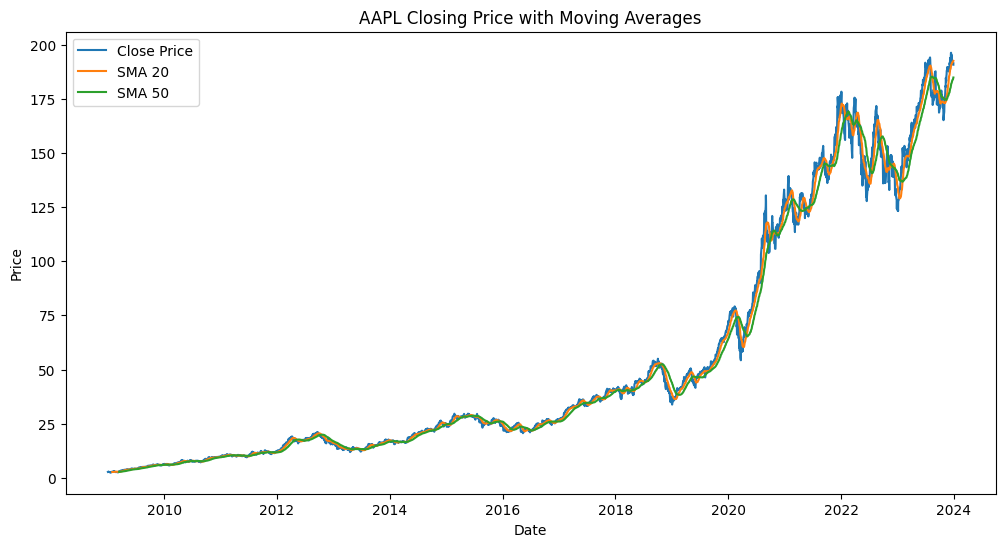

In [6]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')
plt.plot(df['Date'], df['SMA_50'], label='SMA 50')

plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

## Relative Strength Index (RSI)

The RSI is a momentum indicator that measures the speed and magnitude of recent price movements. Values above 70 may indicate overbought conditions, while values below 30 may indicate oversold conditions.

In [7]:
pip install ta-lib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import talib

# Calculate RSI
df['RSI'] = talib.RSI(df['Close'], timeperiod=14)

df[['Date', 'Close', 'RSI']].tail()

,Date,Close,RSI
3769,2023-12-22,191.788757,54.672784
3770,2023-12-26,191.243912,53.090049
3771,2023-12-27,191.342972,53.354446
3772,2023-12-28,191.768951,54.540999
3773,2023-12-29,190.728775,51.121347


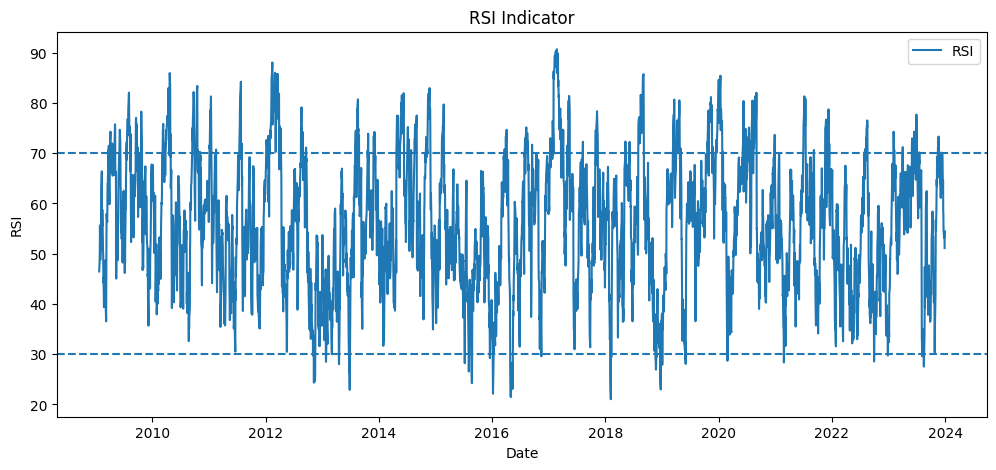

In [9]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['RSI'], label='RSI')

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title("RSI Indicator")
plt.xlabel("Date")
plt.ylabel("RSI")

plt.legend()
plt.show()

## Moving Average Convergence Divergence (MACD)

MACD is used to identify trend direction and momentum shifts by comparing short-term and long-term exponential moving averages.

In [10]:
# MACD calculation
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(df['Close'])

df[['MACD', 'MACD_signal', 'MACD_hist']].tail()

,MACD,MACD_signal,MACD_hist
3769,2.633141,3.235256,-0.602115
3770,2.304751,3.049155,-0.744404
3771,2.029104,2.845145,-0.816041
3772,1.823998,2.640915,-0.816918
3773,1.559539,2.424640,-0.865101


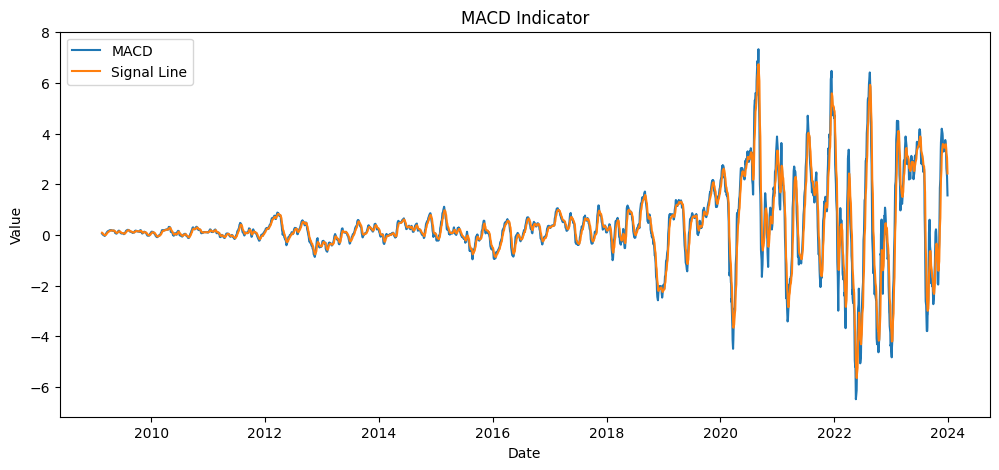

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['MACD'], label='MACD')
plt.plot(df['Date'], df['MACD_signal'], label='Signal Line')

plt.title("MACD Indicator")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend()
plt.show()

## Summary

The stock data was cleaned and analyzed using multiple technical indicators including SMA, EMA, RSI, and MACD.

Key observations:
- Moving averages helped identify overall market trends.
- RSI highlighted overbought and oversold periods.
- MACD revealed momentum shifts and possible trend reversals.

These indicators provide useful insights into stock price behavior and market dynamics.

## Multi-Stock Technical Analysis

In [12]:
stocks = ["AAPL", "AMZN", "GOOG", "META", "NVDA"]

stock_data = {}

for stock in stocks:
    file_path = os.path.join(base_path, "data", f"{stock}.csv")
    
    temp_df = pd.read_csv(file_path)
    
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    
    stock_data[stock] = temp_df

print(stock_data.keys())

dict_keys(['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA'])


In [13]:
for stock, data in stock_data.items():
    
    # Moving averages
    data['SMA_20'] = data['Close'].rolling(window=20).mean()
    data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
    
    # RSI
    data['RSI'] = talib.RSI(data['Close'], timeperiod=14)
    
    # MACD
    data['MACD'], data['MACD_signal'], data['MACD_hist'] = talib.MACD(data['Close'])

print("Indicators calculated successfully.")

Indicators calculated successfully.


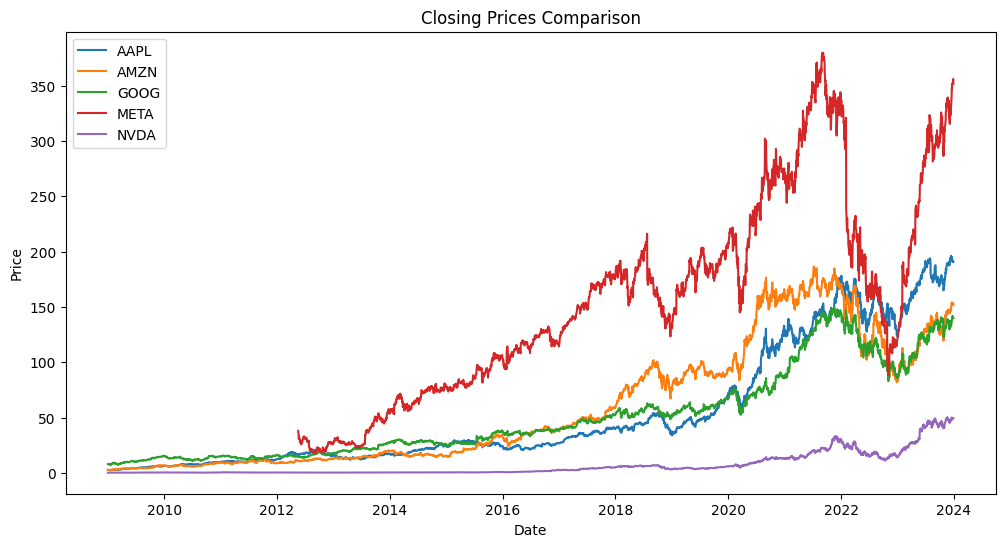

In [14]:
plt.figure(figsize=(12,6))

for stock, data in stock_data.items():
    plt.plot(data['Date'], data['Close'], label=stock)

plt.title("Closing Prices Comparison")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

## Summary

Technical indicators including SMA, EMA, RSI, and MACD were used to analyze stock price behavior across multiple companies.

The analysis revealed:
- long-term market trends,
- momentum shifts,
- overbought and oversold conditions,
- and comparative stock performance.